# Voice Emotion Detection - Complete Workflow

This notebook provides a complete workflow for training and using voice emotion detection models for employee wellness monitoring.

## Overview
- **Data Download**: Automatic download of emotion speech datasets
- **Audio Processing**: Feature extraction from voice recordings
- **Model Training**: Train deep learning models with checkpointing
- **Evaluation**: Comprehensive model evaluation and visualization
- **Inference**: Real-time emotion prediction from voice
- **Export**: Model export for Flutter/mobile deployment

## 1. Setup and Imports

In [4]:
# Install required packages (run only once)
# !pip install torch torchaudio librosa numpy pandas scikit-learn matplotlib seaborn tqdm requests kaggle soundfile tensorboard onnx onnxruntime

import os
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# Import our modules
from data_downloader import EmotionDataDownloader
from audio_processor import AudioProcessor
from emotion_model import EmotionModelFactory, count_parameters
from train import EmotionTrainer
from inference import EmotionPredictor, ModelExporter

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("Setup completed!")
print(f"PyTorch version: {torch.__version__}")
print(f"Device available: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

Setup completed!
PyTorch version: 2.8.0
Device available: CPU


## 2. Data Download and Exploration

In [2]:
# Initialize data downloader
downloader = EmotionDataDownloader(data_dir="data")

# Check dataset information
dataset_info = downloader.get_dataset_info()
print("Available Datasets:")
print(dataset_info.to_string(index=False))

Available Datasets:
Dataset  Available  Audio Files  Emotions                                                Emotion Labels         Path
RAVDESS       True            0         8 neutral, calm, happy, sad, angry, fearful, disgust, surprised data/ravdess
   TESS       True            0         7 angry, disgust, fear, happy, neutral, pleasant_surprised, sad    data/tess
  CREMA       True            0         6                     angry, disgust, fear, happy, neutral, sad   data/crema


In [3]:
# Download datasets (this may take some time)
print("Downloading datasets...")
print("Note: You need to have Kaggle API credentials set up")
print("1. Create account at kaggle.com")
print("2. Go to Account -> API -> Create New API Token")
print("3. Place kaggle.json in ~/.kaggle/ directory")

# Download smaller datasets first for faster experimentation
datasets_to_download = ['ravdess', 'tess']
successful_downloads = []

for dataset in datasets_to_download:
    if downloader.download_dataset(dataset):
        successful_downloads.append(dataset)

print(f"\nSuccessfully downloaded: {successful_downloads}")

Note: You need to have Kaggle API credentials set up
1. Create account at kaggle.com
2. Go to Account -> API -> Create New API Token
3. Place kaggle.json in ~/.kaggle/ directory
Dataset ravdess already available at data/ravdess
Dataset tess already available at data/tess

Successfully downloaded: ['ravdess', 'tess']


Total audio files: 8082


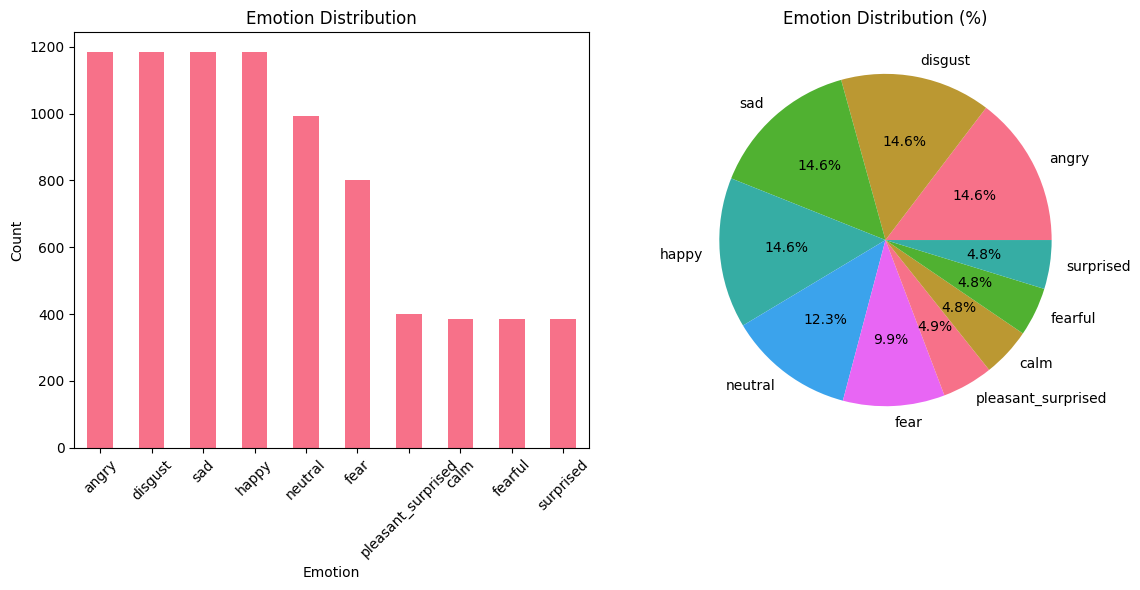


Emotion Statistics:
  angry: 1184 samples (14.6%)
  disgust: 1184 samples (14.6%)
  sad: 1184 samples (14.6%)
  happy: 1184 samples (14.6%)
  neutral: 992 samples (12.3%)
  fear: 800 samples (9.9%)
  pleasant_surprised: 400 samples (4.9%)
  calm: 386 samples (4.8%)
  fearful: 384 samples (4.8%)
  surprised: 384 samples (4.8%)


In [4]:
# Explore the downloaded data
if successful_downloads:
    file_paths, labels = downloader.get_file_paths_and_labels(successful_downloads)
    
    print(f"Total audio files: {len(file_paths)}")
    
    # Create emotion distribution plot
    emotion_counts = pd.Series(labels).value_counts()
    
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    emotion_counts.plot(kind='bar')
    plt.title('Emotion Distribution')
    plt.xlabel('Emotion')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    
    plt.subplot(1, 2, 2)
    plt.pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%')
    plt.title('Emotion Distribution (%)')
    
    plt.tight_layout()
    plt.show()
    
    print("\nEmotion Statistics:")
    for emotion, count in emotion_counts.items():
        percentage = (count / len(labels)) * 100
        print(f"  {emotion}: {count} samples ({percentage:.1f}%)")
else:
    print("No datasets downloaded. Please check your Kaggle credentials.")

## 3. Audio Processing and Feature Extraction

In [5]:
# Initialize audio processor
processor = AudioProcessor(
    sample_rate=22050,
    duration=3.0,
    n_mfcc=13,
    n_mels=128
)

print("Audio Processor Configuration:")
print(f"  Sample Rate: {processor.sample_rate} Hz")
print(f"  Duration: {processor.duration} seconds")
print(f"  MFCC coefficients: {processor.n_mfcc}")
print(f"  Mel bands: {processor.n_mels}")

Audio Processor Configuration:
  Sample Rate: 22050 Hz
  Duration: 3.0 seconds
  MFCC coefficients: 13
  Mel bands: 128


## 4. Model Training

In [2]:
# Training configuration
training_config = {
    'model_type': 'cnn',  # Choose: 'cnn', 'rnn', 'transformer', 'hybrid'
    'epochs': 20,
    'batch_size': 16,
    'datasets': successful_downloads if 'successful_downloads' in locals() else ['ravdess'],
    'resume_from': None  # Set to checkpoint path to resume training
}

print(f"Training Configuration:")
for key, value in training_config.items():
    print(f"  {key}: {value}")

Training Configuration:
  model_type: cnn
  epochs: 20
  batch_size: 16
  datasets: ['ravdess']
  resume_from: None


In [7]:
# Initialize and run training
trainer = EmotionTrainer(
    model_type=training_config['model_type'],
    model_params={},
    data_dir='data',
    checkpoint_dir='checkpoints',
    log_dir='logs'
)

# Prepare data and train
if 'successful_downloads' in locals() and successful_downloads:
    trainer.prepare_data(
        datasets=training_config['datasets'],
        batch_size=training_config['batch_size'],
        num_workers=2
    )
    
    trainer.create_model()
    
    trainer.train(
        epochs=training_config['epochs'],
        resume_from=training_config['resume_from'],
        save_every=5
    )
    
    # Evaluate
    results = trainer.evaluate()
    print(f"Test Accuracy: {results['accuracy']:.4f}")
else:
    print("No datasets available for training.")

EmotionTrainer initialized
Model type: cnn
Device: cpu
Checkpoint directory: checkpoints
Log directory: logs
Preparing data...
Total samples: 8082
Dataset initialized with 8082 samples
Emotion classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fear'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('pleasant_surprised'), np.str_('sad'), np.str_('surprised')]
Class distribution: {np.str_('angry'): np.int64(1184), np.str_('calm'): np.int64(386), np.str_('disgust'): np.int64(1184), np.str_('fear'): np.int64(800), np.str_('fearful'): np.int64(384), np.str_('happy'): np.int64(1184), np.str_('neutral'): np.int64(992), np.str_('pleasant_surprised'): np.int64(400), np.str_('sad'): np.int64(1184), np.str_('surprised'): np.int64(384)}
Train samples: 5657
Validation samples: 1212
Test samples: 1213
Fitting feature scalers...


Processing training samples: 100%|██████████| 1000/1000 [01:19<00:00, 12.51it/s]


Data preparation completed!
Creating cnn model...
Model created with 430,602 parameters
Starting training for 20 epochs...

Epoch 1/20
--------------------------------------------------


Epoch 1 [Train]:   0%|          | 0/354 [00:00<?, ?it/s]/Users/joshuageorge/Desktop/Projects/Python/feelings-detection-from-voice/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/joshuageorge/Desktop/Projects/Python/feelings-detection-from-voice/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Epoch 1 [Val]:   0%|          | 0/76 [00:00<?, ?it/s]/Users/joshuageorge/Desktop/Projects/Python/feelings-detection-from-voice/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL

Train Loss: 1.3925, Train Acc: 49.18%
Val Loss: 1.8039, Val Acc: 41.42%
Best model saved to checkpoints/cnn_best.pth

Epoch 2/20
--------------------------------------------------


...

Train Loss: 0.1535, Train Acc: 94.64%
Val Loss: 0.7112, Val Acc: 82.18%

Epoch 20/20
--------------------------------------------------


Epoch 20 [Train]:   0%|          | 0/354 [00:00<?, ?it/s]/Users/joshuageorge/Desktop/Projects/Python/feelings-detection-from-voice/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/joshuageorge/Desktop/Projects/Python/feelings-detection-from-voice/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Epoch 20 [Val]:   0%|          | 0/76 [00:00<?, ?it/s]/Users/joshuageorge/Desktop/Projects/Python/feelings-detection-from-voice/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreS

Train Loss: 0.1512, Train Acc: 94.64%
Val Loss: 0.4355, Val Acc: 87.79%

Training completed! Best validation accuracy: 90.10%


Evaluating:   0%|          | 0/76 [00:00<?, ?it/s]/Users/joshuageorge/Desktop/Projects/Python/feelings-detection-from-voice/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/joshuageorge/Desktop/Projects/Python/feelings-detection-from-voice/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Evaluating: 100%|██████████| 76/76 [00:47<00:00,  1.59it/s]


Evaluation Results:
Accuracy: 0.8631
Loss: 0.5060

Classification Report:
                    precision    recall  f1-score   support

             angry       0.99      0.91      0.95       179
              calm       0.89      0.36      0.51        67
           disgust       0.89      0.94      0.92       184
              fear       0.99      1.00      1.00       135
           fearful       1.00      0.37      0.53        63
             happy       0.71      0.95      0.81       152
           neutral       0.83      0.99      0.90       144
pleasant_surprised       0.99      1.00      0.99        71
               sad       0.75      0.94      0.84       161
         surprised       1.00      0.35      0.52        57

          accuracy                           0.86      1213
         macro avg       0.90      0.78      0.80      1213
      weighted avg       0.88      0.86      0.85      1213

Test Accuracy: 0.8631


## 5. Model Inference and Export

In [5]:
# Load trained model for inference
model_path = f"checkpoints/{training_config['model_type']}_best.pth"

if Path(model_path).exists():
    predictor = EmotionPredictor(model_path)
    print("Model loaded for inference!")
    print(f"Emotion classes: {list(predictor.emotion_classes)}")
    
    # Test with dummy audio
    dummy_audio = np.random.randn(22050 * 3)
    result = predictor.predict_from_audio_data(dummy_audio, 22050)
    print(f"\nSample prediction: {result['predicted_emotion']} (confidence: {result['confidence']:.3f})")
    
    # Export model for deployment
    exporter = ModelExporter(model_path)
    exporter.create_deployment_package("deployment")
    print("\nModel exported for deployment!")
else:
    print(f"Model not found. Please train a model first.")

Loading model from checkpoints/cnn_best.pth
Model loaded successfully!
Model type: cnn
Device: cpu
Emotion classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fear'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('pleasant_surprised'), np.str_('sad'), np.str_('surprised')]
Model loaded for inference!
Emotion classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fear'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('pleasant_surprised'), np.str_('sad'), np.str_('surprised')]

Sample prediction: disgust (confidence: 0.741)
Model successfully exported to ONNX: deployment/model.onnx
Model successfully exported to TorchScript: deployment/model.pt
Deployment package created successfully: deployment

Model exported for deployment!
